Pre-Processes Data and Trains Model (RUN FIRST)

Preprocessing....

Training model... please be patient :)



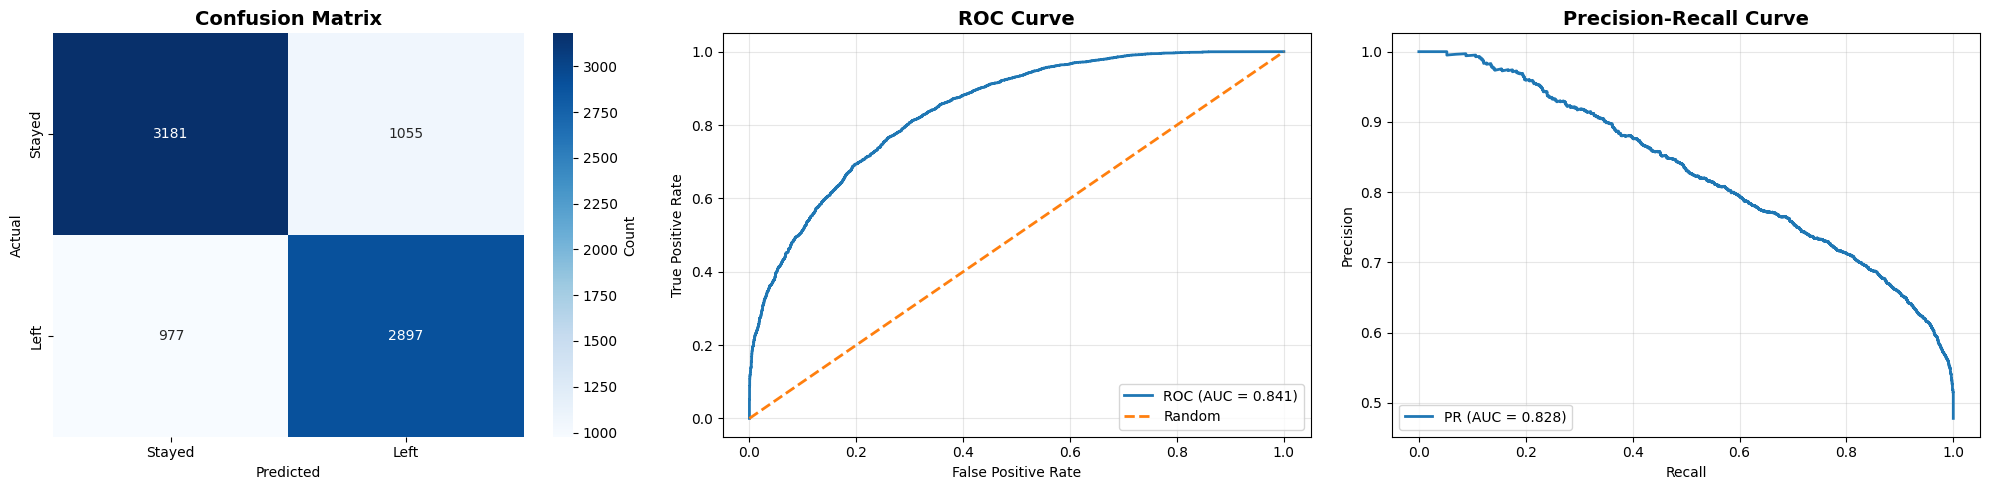

In [2]:
import warnings, os, numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, precision_recall_fscore_support
)
warnings.filterwarnings('ignore')

# configurations
CSV_PATH = "train.csv"
ENCODING_DICTIONARY = {
    'Work-Life Balance': {'Poor':1,'Fair':2,'Good':3,'Excellent':4},
    'Job Satisfaction': {'Low':1,'Medium':2,'High':3,'Very High':4},
    'Employee Recognition': {'Low':1,'Medium':2,'High':3,'Very High':4},
    'Performance Rating': {'Below Average':1,'Low':2,'Average':3,'High':4},
    'Company Reputation': {'Poor':1,'Fair':2,'Good':3,'Excellent':4},
    'Education Level': {'High School':1,'Associate Degree':2,"Bachelor's Degree":3,"Master's Degree":4,'PhD':5},
    'Job Level': {'Entry':1,'Mid':2,'Senior':3},
    'Company Size': {'Small':1,'Medium':2,'Large':3},
    'Gender': {'Female':0,'Male':1},
    'Job Role': {'Education':0,'Finance':1,'Healthcare':2,'Media':3,'Technology':4},
    'Marital Status': {'Divorced':0,'Married':1,'Single':2},
    'Overtime': {'No':0,'Yes':1},
    'Remote Work': {'No':0,'Yes':1},
    'Leadership Opportunities': {'No':0,'Yes':1},
    'Innovation Opportunities': {'No':0,'Yes':1},
    'Attrition': {'Stayed':0,'Left':1},
}

DECODING_DICTIONARY = {c:{v:k for k,v in m.items()} for c,m in ENCODING_DICTIONARY.items()}

# Data procesing pipline, includes normalization validation
def load_and_preprocess():
    assert os.path.exists(CSV_PATH), f"CSV not found at: {CSV_PATH}"
    df = pd.read_csv(CSV_PATH)

    # ' vs curly apostrophe bug , use ansi value
    for c in df.select_dtypes('object'):
        df[c] = (df[c].astype(str).str.strip()
                 .str.replace('[\u2018\u2019`]', "'", regex=True)
                 .str.replace('[\u201c\u201d]', '"', regex=True)
                 .str.replace(r'\s+', ' ', regex=True))
    df_original = df.copy()

    if {'Age','Years at Company'}.issubset(df.columns):
        df = df.query('18 <= Age <= 70').query('`Years at Company` >= 0') \
               .query('`Years at Company` <= Age').query('Age - `Years at Company` >= 16')
    else:
        if 'Age' in df: df = df.query('18 <= Age <= 70')
        if 'Years at Company' in df: df = df.query('`Years at Company` >= 0')
    if 'Monthly Income' in df: df = df.query('`Monthly Income` > 0')
    for col in ['Number of Promotions','Number of Dependents','Distance from Home']:
        if col in df: df = df.query(f'`{col}` >= 0')

    # remove columns that dont matter
    drop_cols = ["Employee ID","EmployeeCount","Over18","StandardHours","EmployeeNumber"]
    df.drop(columns=[c for c in drop_cols if c in df], errors='ignore', inplace=True)


    obj_cols = df.select_dtypes('object').columns.tolist()
    missing = set(obj_cols) - set(ENCODING_DICTIONARY.keys())
    if missing: raise ValueError(f"These columns are not in ENCODING_DICTIONARY: {missing}")
    for c, m in ENCODING_DICTIONARY.items():
        if c in df: df[c] = df[c].map(m)
    na_bad = df.isna().sum() #prevent NaN bug
    na_bad = na_bad[na_bad > 0]
    if len(na_bad): raise ValueError("NaNs introduced by encoding:\n" + na_bad.to_string())


    bins = {
        'Years at Company': ([0,2,5,10,50], 'Tenure_Bucket'),
        'Age': ([17,30,40,50,71], 'Age_Bucket'),
        'Monthly Income': ([-1,5000,7000,9000,999999], 'Income_Bucket'),
        'Distance from Home': ([0,10,25,50,100], 'Distance_Bucket'),
        'Company Tenure': ([-1,10,30,60,999], 'Company_Age_Bucket')
    }
    for col, (b, lab) in bins.items():
        if col in df:
            df[lab] = pd.cut(df[col], bins=b, labels=range(1, len(b)), include_lowest=True).astype(int)

    # Continuous Values -> buckets
    df.drop(columns=[c for c in ['Years at Company','Age','Monthly Income','Distance from Home','Company Tenure'] if c in df],
            errors='ignore', inplace=True)

    return df, df_original

def train_model(X_train, y_train):
    return RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_split=5, min_samples_leaf=2,
        max_features='sqrt', class_weight='balanced_subsample',
        random_state=42, n_jobs=-1, bootstrap=True
    ).fit(X_train, y_train)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return y_pred, y_proba, accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, pos_label=1), roc_auc_score(y_test, y_proba)

def plot_metrics(y_test, y_pred, y_proba, roc_auc):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'],
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], lw=2, ls='--', label='Random')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold'); axes[1].legend(loc='lower right'); axes[1].grid(True, alpha=.3)

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    axes[2].plot(recall, precision, lw=2, label=f'PR (AUC = {pr_auc:.3f})')
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold'); axes[2].legend(loc='lower left'); axes[2].grid(True, alpha=.3)

    plt.tight_layout(); plt.show()

# main fx
if __name__ == "__main__":
    df, df_original = load_and_preprocess()
    print("Preprocessing....\n")
    y = df['Attrition']; X = df.drop('Attrition', axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)
    print("Training model... please be patient :)\n")
    model = train_model(X_train, y_train)
    y_pred, y_proba, accuracy, f1, roc_auc = evaluate_model(model, X_test, y_test)
    #print_metrics(y_test, y_pred)
    plot_metrics(y_test, y_pred, y_proba, roc_auc)


OVERVIEW OF DATA



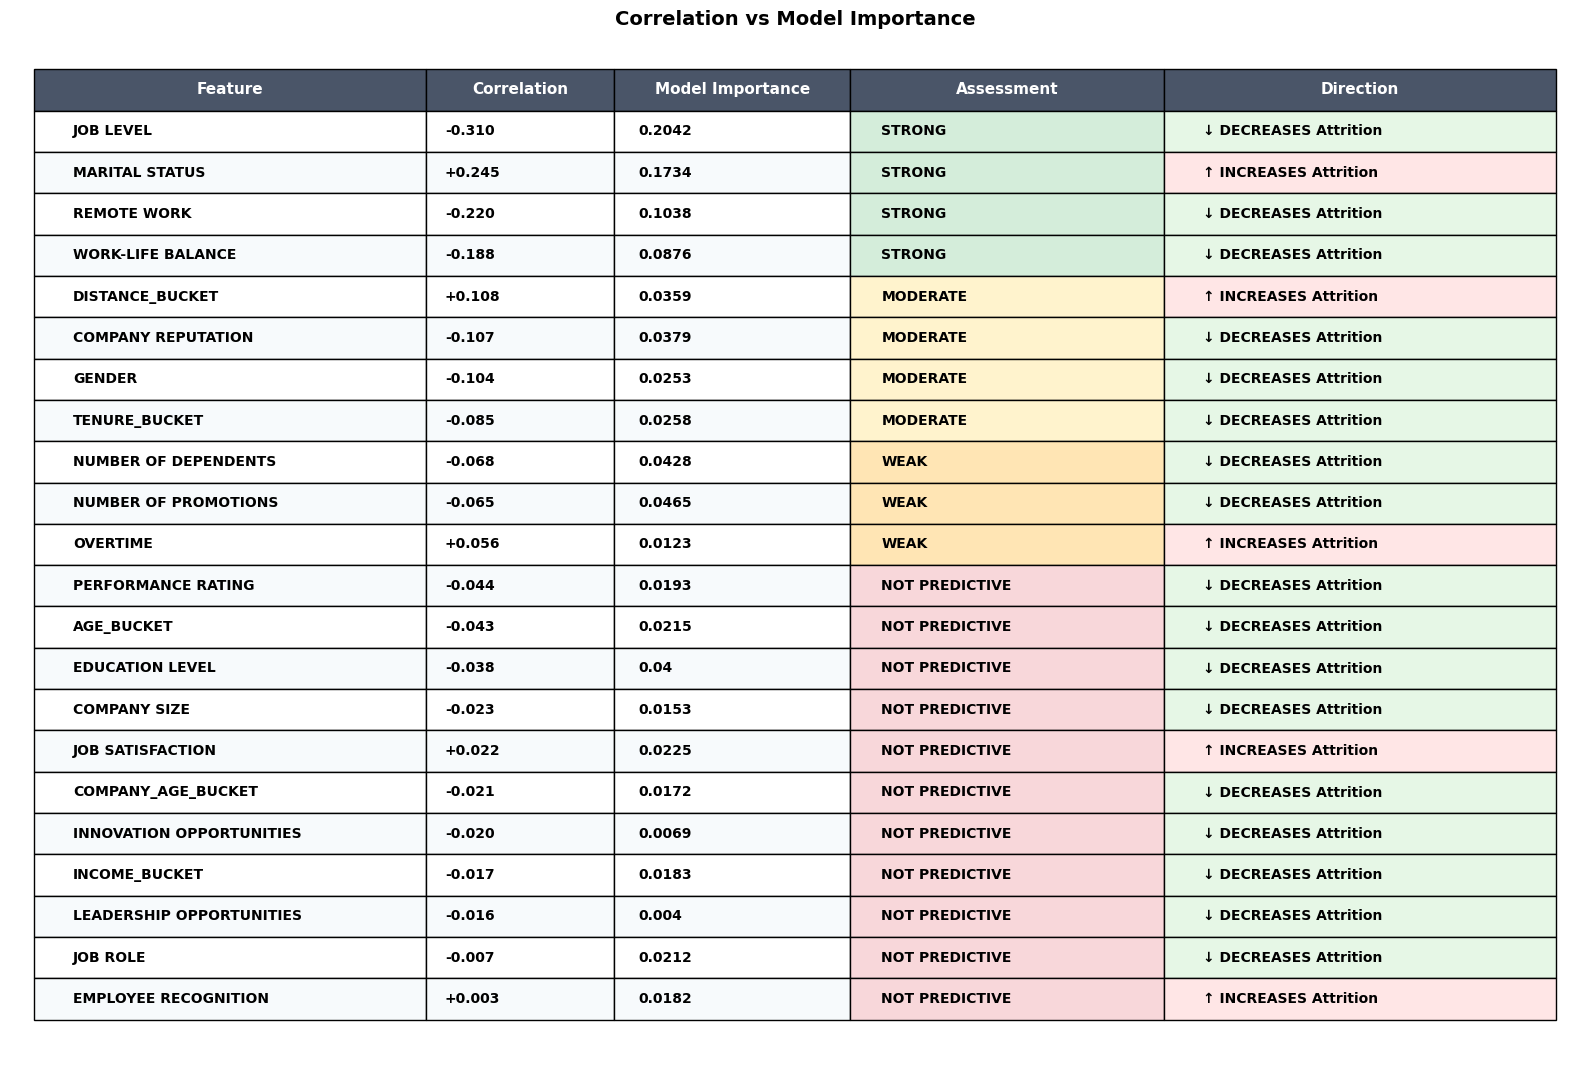

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from __main__ import X_train, y_train, model

def build_comparison_df(X, y, model, method='spearman', top_k=None):
    df = X.copy()
    df['Attrition'] = y.values if hasattr(y, 'values') else y
    corr = df.corr(numeric_only=True, method=method)['Attrition'].drop('Attrition', errors='ignore')
    imp = pd.Series(getattr(model, 'feature_importances_', np.zeros(X.shape[1])), index=X.columns)
    abs_corr = corr.reindex(imp.index).abs()

    out = pd.DataFrame({
        'Feature': imp.index.str.upper(),
        'Correlation': corr.reindex(imp.index).map(lambda x: f"{x:+.3f}" if pd.notna(x) else 'NaN'),
        'Model Importance': imp.values.round(4),
        'Assessment': np.select([abs_corr > 0.15, abs_corr > 0.08, abs_corr > 0.05, abs_corr.isna()],
                                ['STRONG', 'MODERATE', 'WEAK', 'N/A'], default='NOT PREDICTIVE'),
        'Direction': np.where(corr.reindex(imp.index) > 0, '↑ INCREASES Attrition',
                     np.where(corr.reindex(imp.index) < 0, '↓ DECREASES Attrition', 'N/A'))
    }).sort_values('Correlation', key=lambda c: c.str.replace('+','').astype(float).abs(), ascending=False)

    return out.head(top_k) if top_k else out

def render_table(df):
    fig, ax = plt.subplots(figsize=(16, max(2, 0.4*len(df)+2)))
    ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='left', loc='center',
                     colWidths=[0.25,0.12,0.15,0.20,0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1,2)


    for key, cell in table.get_celld().items():
        cell.get_text().set_fontweight('bold')
        if key[0] == 0:
            cell.set_facecolor('#4a5568')
            cell.set_text_props(color='white', size=11)


    colors = {'STRONG': '#d4edda', 'MODERATE': '#fff3cd', 'WEAK': '#ffe5b4', 'NOT': '#f8d7da'}
    col_idx = {c:i for i,c in enumerate(df.columns)}

    for i in range(1, len(df)+1):
        assess, direct = df.iloc[i-1, col_idx['Assessment']], df.iloc[i-1, col_idx['Direction']]
        table[(i, col_idx['Assessment'])].set_facecolor(next((v for k,v in colors.items() if k in assess), 'white'))
        table[(i, col_idx['Direction'])].set_facecolor('#ffe6e6' if '↑' in direct else '#e6f7e6' if '↓' in direct else 'white')

        if i%2==0:
            for j in [j for j in range(len(df.columns)) if j not in [col_idx['Assessment'], col_idx['Direction']]]:
                if table[(i,j)].get_facecolor()==(1,1,1,1):
                    table[(i,j)].set_facecolor('#f7fafc')

    plt.title('Correlation vs Model Importance', fontsize=14, fontweight='bold', pad=-20)
    plt.tight_layout()
    plt.show()

if 'X_train' in globals() and 'model' in globals():
    render_table(build_comparison_df(X_train, y_train, model))
else:
    print("Please run Cell 1 first.")

QUESTIONS

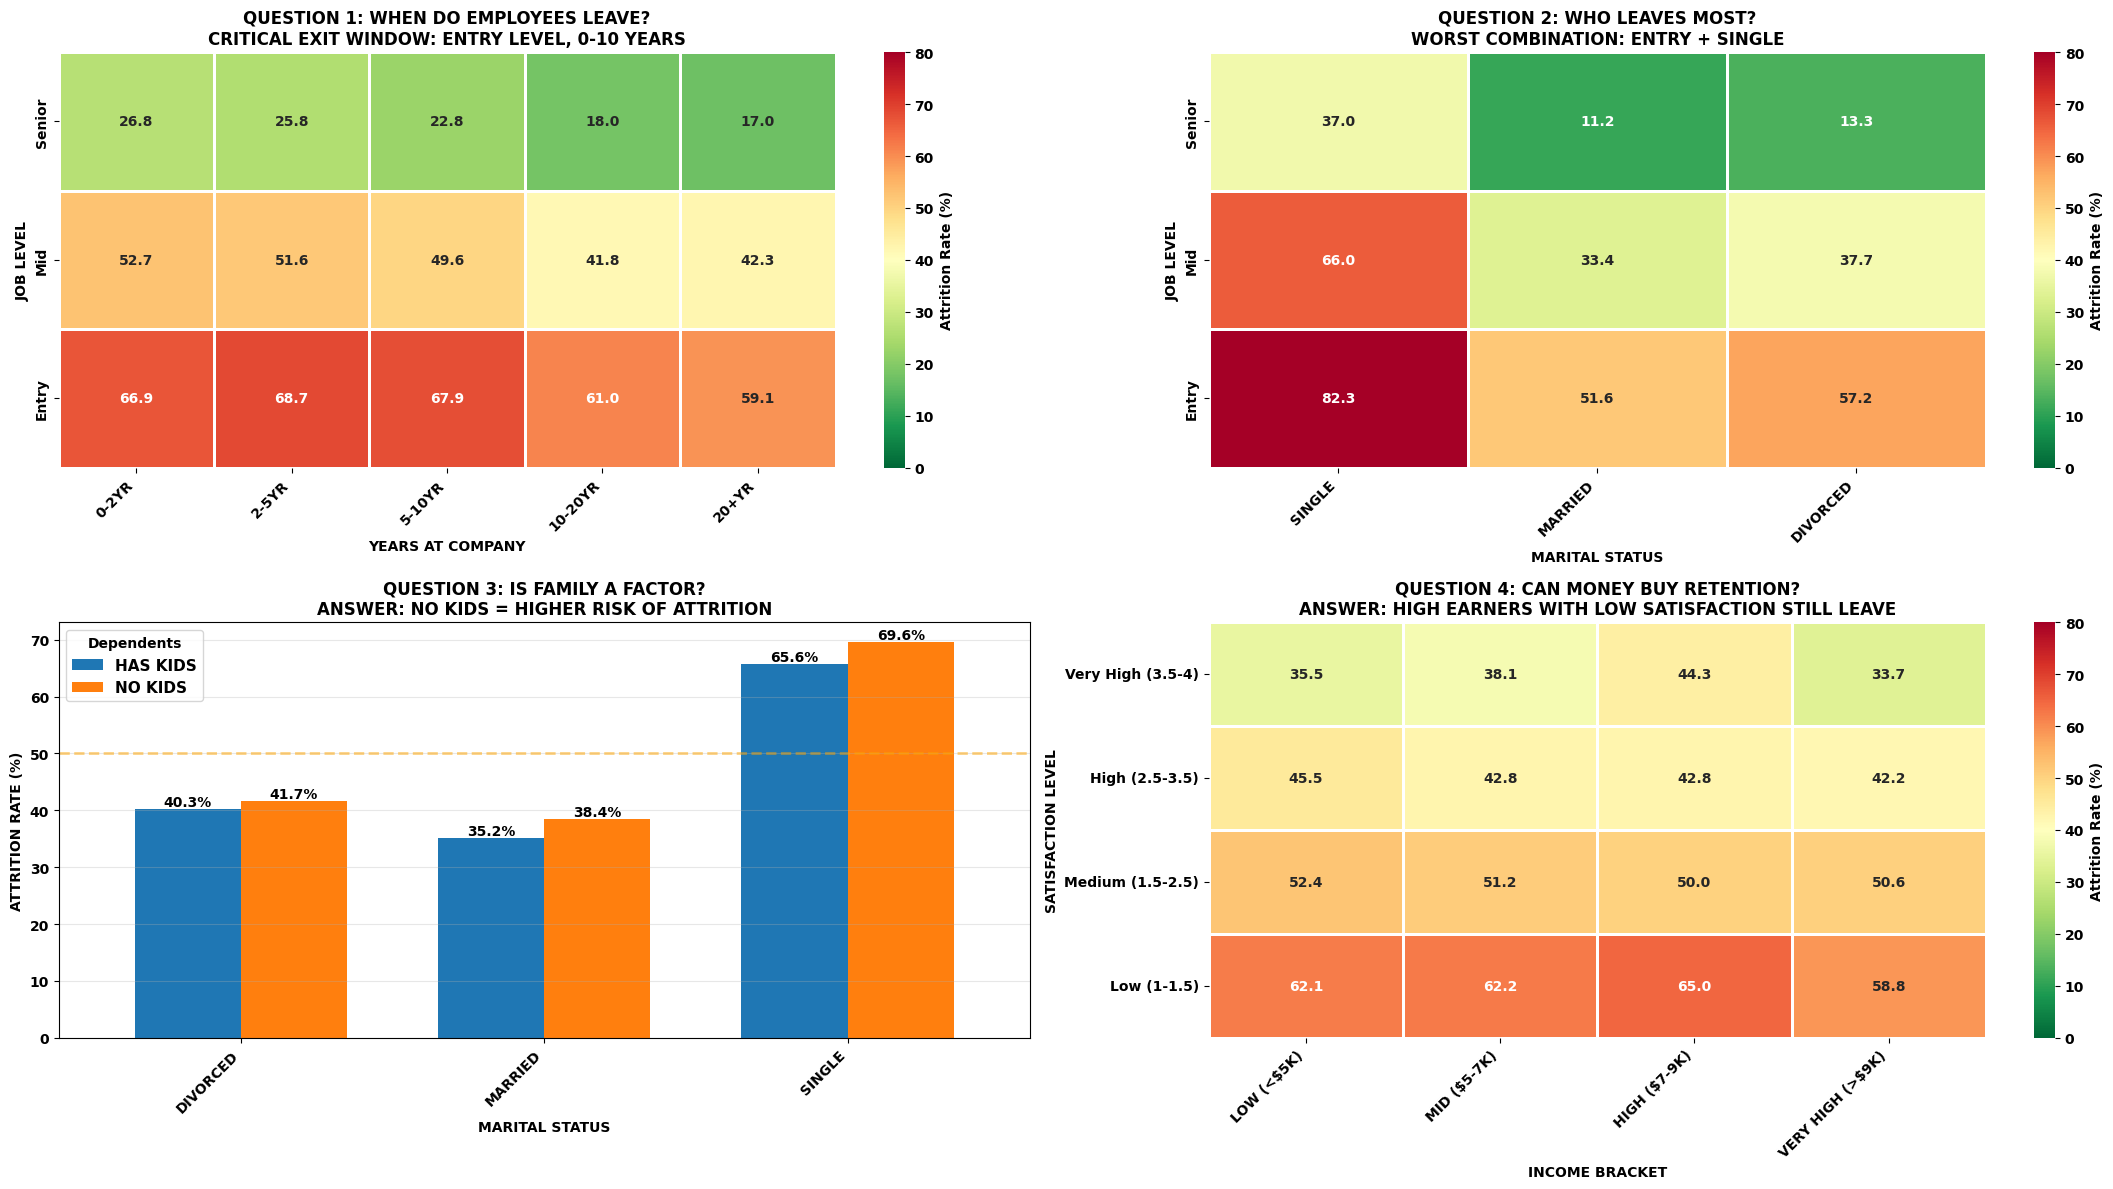

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

# force upppercase
def upper_axes(ax):
    ax.set_title(ax.get_title().upper())
    ax.set_xlabel(ax.get_xlabel().upper())
    ax.set_ylabel(ax.get_ylabel().upper())
    ax.set_xticklabels([t.get_text().upper() for t in ax.get_xticklabels()], rotation=45, ha='right')
    if ax.get_legend():
        for text in ax.get_legend().get_texts():
            text.set_text(text.get_text().upper())

def create_visualization_features(df_original):
    df = df_original.copy()

    # Normalize all object/string-like cols
    obj_cols = df.select_dtypes('object').columns
    if len(obj_cols):
        norm = (df[obj_cols].astype(str)
                .apply(lambda s: s.str.strip()
                       .str.replace(r"[\u2018\u2019`]", "'", regex=True)
                       .str.replace(r'[\u201c\u201d]', '"', regex=True)
                       .str.replace(r'\s+', ' ', regex=True)))
        df[obj_cols] = norm

    # Buckets
    df['Tenure_Bucket']  = pd.cut(df['Years at Company'],
                                  bins=[0,2,5,10,20,50],
                                  labels=['0-2yr','2-5yr','5-10yr','10-20yr','20+yr'])
    df['Income_Bracket'] = pd.cut(df['Monthly Income'],
                                  bins=[0,5000,7000,9000,15000],
                                  labels=['Low (<$5K)','Mid ($5-7K)','High ($7-9K)','Very High (>$9K)'])

    # Satisfaction  numeric + rollup
    sat_map  = {'Low':1,'Medium':2,'High':3,'Very High':4,'Poor':1,'Fair':2,'Good':3,'Excellent':4}
    sat_cols = ['Work-Life Balance','Job Satisfaction','Employee Recognition']
    for c in sat_cols:
        df[f'{c}_Numeric'] = df[c].map(sat_map)
    df['SatisfactionMean'] = df[[f'{c}_Numeric' for c in sat_cols]].mean(axis=1)
    df['Satisfaction_Category'] = pd.cut(df['SatisfactionMean'],
                                         bins=[0,1.5,2.5,3.5,4.5],
                                         labels=['Low (1-1.5)','Medium (1.5-2.5)','High (2.5-3.5)','Very High (3.5-4)'])


    df['Has_Dependents'] = np.where(df['Number of Dependents'].fillna(0).gt(0), 'Has Kids', 'No Kids')
    return df


RATE = lambda s: s.eq('Left').mean() * 100

def heatmap_rate(df, index, columns, ax, *, title, xlabel, ylabel,
                 order_index=None, order_cols=None, vmin=0, vmax=80):
    pt = df.pivot_table(values='Attrition', index=index, columns=columns, aggfunc=RATE)
    if order_index is not None:
        pt = pt.reindex(order_index)
    if order_cols is not None:
        pt = pt.reindex(order_cols, axis=1)

    sns.heatmap(pt, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
                cbar_kws={'label':'Attrition Rate (%)'}, vmin=vmin, vmax=vmax,
                linewidths=2, linecolor='white')
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.invert_yaxis()
    upper_axes(ax)
    return ax

def bar_rate_by(df, by_a, by_b, ax, *, title, xlabel, ylabel, legend_title=''):
    # P(Left|by_a, by_b)
    ct = (pd.crosstab([df[by_a], df[by_b]], df['Attrition'], normalize='index')
            .get('Left', pd.Series(0, index=[]))
            .unstack(by_b)
            .mul(100))
    ct.plot(kind='bar', ax=ax, width=0.7)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.legend(title=legend_title, fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5, linewidth=2)
    for cont in ax.containers:
        ax.bar_label(cont, fmt='%.1f%%', fontsize=10, fontweight='bold')
    upper_axes(ax)
    return ax

def plot_tenure_by_level(df, ax):
    return heatmap_rate(
        df, index='Job Level', columns='Tenure_Bucket', ax=ax,
        title='Question 1: WHEN Do Employees Leave?\nCritical Exit Window: Entry Level, 0-10 Years',
        xlabel='Years at Company', ylabel='Job Level'
    )

def plot_marital_by_level(df, ax):
    return heatmap_rate(
        df, index='Job Level', columns='Marital Status', ax=ax,
        title='Question 2: WHO Leaves Most?\nWorst Combination: Entry + Single',
        xlabel='Marital Status', ylabel='Job Level',
        order_cols=['Single','Married','Divorced']
    )

def plot_dependents_impact(df, ax):
    return bar_rate_by(
        df, by_a='Marital Status', by_b='Has_Dependents', ax=ax,
        title='Question 3: Is Family a Factor?\nAnswer: No Kids = Higher Risk of Attrition',
        xlabel='Marital Status', ylabel='Attrition Rate (%)', legend_title='Dependents'
    )

def plot_satisfaction_income(df, ax):
    """Q4: Can money buy retention?"""
    sat_order = ['Low (1-1.5)', 'Medium (1.5-2.5)', 'High (2.5-3.5)', 'Very High (3.5-4)']
    return heatmap_rate(
        df, index='Satisfaction_Category', columns='Income_Bracket', ax=ax,
        title='Question 4: Can Money Buy Retention?\nAnswer: High Earners with Low Satisfaction STILL Leave',
        xlabel='Income Bracket', ylabel='Satisfaction Level',
        order_index=sat_order
    )

def render_attrition_quadrant(df_original, *, figsize=(22, 12)):
    df = create_visualization_features(df_original)
    fig = plt.figure(figsize=figsize)
    plot_tenure_by_level(df, plt.subplot(2,2,1))
    plot_marital_by_level(df, plt.subplot(2,2,2))
    plot_dependents_impact(df, plt.subplot(2,2,3))
    plot_satisfaction_income(df, plt.subplot(2,2,4))
    plt.tight_layout()
    return fig

#main
fig = render_attrition_quadrant(df_original)
plt.show()


SOLUTIONS

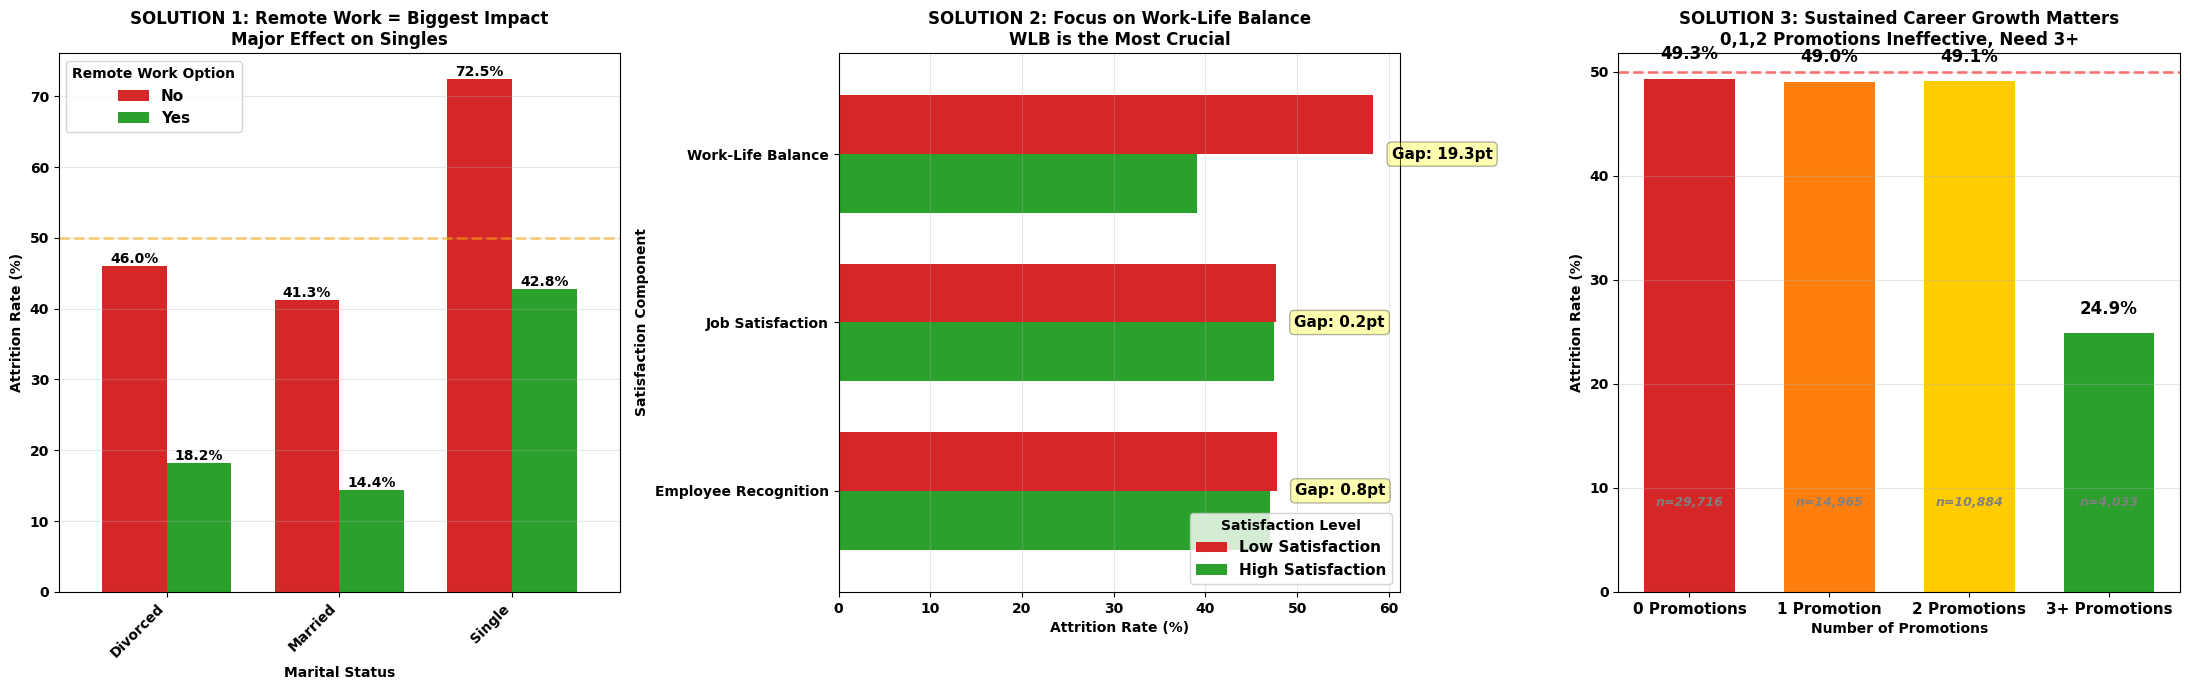

In [5]:
import matplotlib.pyplot as plt, seaborn as sns, pandas as pd, numpy as np

def create_solution_features(df_original):
    """Apply feature engineering for solution analysis (reuses patterns from Cell 3)"""
    df = df_original.copy()

    # Normalize
    obj_cols = df.select_dtypes('object').columns
    if len(obj_cols):
        norm = (df[obj_cols].astype(str)
                .apply(lambda s: s.str.strip()
                       .str.replace(r"[\u2018\u2019`]", "'", regex=True)
                       .str.replace(r'[\u201c\u201d]', '"', regex=True)
                       .str.replace(r'\s+', ' ', regex=True)))
        df[obj_cols] = norm

    # Satisfaction scoring
    sat_map = {'Low':1,'Medium':2,'High':3,'Very High':4,'Poor':1,'Fair':2,'Good':3,'Excellent':4}
    sat_cols = ['Work-Life Balance','Job Satisfaction','Employee Recognition']
    for c in sat_cols:
        df[f'{c}_Numeric'] = df[c].map(sat_map)

    df['SatisfactionMean'] = df[[f'{c}_Numeric' for c in sat_cols]].mean(axis=1)
    df['Satisfaction_Category'] = pd.cut(df['SatisfactionMean'],
                                          bins=[0,1.5,2.5,3.5,4.5],
                                          labels=['Low (1-1.5)','Medium (1.5-2.5)','High (2.5-3.5)','Very High (3.5-4)'])

    df['Promotion_Bucket'] = df['Number of Promotions'].apply(
        lambda x: '0 Promotions' if x==0 else '1 Promotion' if x==1
                  else '2 Promotions' if x==2 else '3+ Promotions')

    return df

# Reuse rate
RATE = lambda s: s.eq('Left').mean() * 100

def bar_rate_by(df, by_a, by_b, ax, *, title, xlabel, ylabel, legend_title='', colors=None):
    """Reusable bar chart for attrition rates by two variables (similar to Cell 3's bar_rate_by)"""
    ct = (pd.crosstab([df[by_a], df[by_b]], df['Attrition'], normalize='index')
            .get('Left', pd.Series(0, index=[]))
            .unstack(by_b)
            .mul(100))
    ct.plot(kind='bar', ax=ax, width=0.75, color=colors or ['#d62728','#2ca02c'])
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.legend(title=legend_title, fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5, linewidth=2)
    for cont in ax.containers:
        ax.bar_label(cont, fmt='%.1f%%', fontsize=10, fontweight='bold')
    return ax

def plot_remote_work_impact(df, ax):
    """Solution 1: Remote work effectiveness"""
    return bar_rate_by(
        df, by_a='Marital Status', by_b='Remote Work', ax=ax,
        title='SOLUTION 1: Remote Work = Biggest Impact\nMajor Effect on Singles',
        xlabel='Marital Status', ylabel='Attrition Rate (%)',
        legend_title='Remote Work Option',
        colors=['#d62728','#2ca02c']
    )

def plot_satisfaction_components(df, ax):
    """Solution 2: Satisfaction component analysis"""
    sat_cols = ['Work-Life Balance','Job Satisfaction','Employee Recognition']
    component_impact = {
        col: {
            'Low Satisfaction': df[df[f'{col}_Numeric']<=2]['Attrition'].apply(lambda x: 1 if x=='Left' else 0).mean()*100,
            'High Satisfaction': df[df[f'{col}_Numeric']>=3]['Attrition'].apply(lambda x: 1 if x=='Left' else 0).mean()*100
        }
        for col in sat_cols
    }

    component_df = pd.DataFrame(component_impact).T
    component_df['Gap'] = component_df['Low Satisfaction'] - component_df['High Satisfaction']

    component_df[['Low Satisfaction','High Satisfaction']].plot(
        kind='barh', ax=ax, color=['#d62728','#2ca02c'], width=0.7)
    ax.set(xlabel='Attrition Rate (%)', ylabel='Satisfaction Component',
           title='SOLUTION 2: Focus on Work-Life Balance\nWLB is the Most Crucial')
    ax.legend(['Low Satisfaction','High Satisfaction'], title='Satisfaction Level', loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

    for i, (idx, row) in enumerate(component_df.iterrows()):
        x_pos = max(row['Low Satisfaction'], row['High Satisfaction']) + 2
        ax.text(x_pos, i, f'Gap: {row["Gap"]:.1f}pt', va='center', fontweight='bold', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    return ax

def plot_promotion_impact(df, ax):
    """Solution 3: Career growth analysis"""
    promo_order = ['0 Promotions','1 Promotion','2 Promotions','3+ Promotions']
    attrition_by_promo = df.groupby('Promotion_Bucket')['Attrition'].apply(RATE).reindex(promo_order)

    colors = ['#d62728','#ff7f0e','#ffcc00','#2ca02c']
    bars = ax.bar(range(len(attrition_by_promo)), attrition_by_promo.values, color=colors, width=0.65)
    ax.set(xlabel='Number of Promotions', ylabel='Attrition Rate (%)',
           title='SOLUTION 3: Sustained Career Growth Matters\n0,1,2 Promotions Ineffective, Need 3+')
    ax.set_xticks(range(len(attrition_by_promo)))
    ax.set_xticklabels(promo_order, rotation=0, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, linewidth=2, label='50% baseline')

    for i, (bar, val) in enumerate(zip(bars, attrition_by_promo.values)):
        ax.text(bar.get_x()+bar.get_width()/2, val+1.5, f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
        count = len(df[df['Promotion_Bucket']==promo_order[i]])
        ax.text(i, 8, f'n={count:,}', ha='center', va='bottom', fontsize=9,
                style='italic', color='gray')
    return ax

def render_solution_dashboard(df_original, *, figsize=(22,7)):
    """Generate complete solution analysis dashboard"""
    df = create_solution_features(df_original)
    fig = plt.figure(figsize=figsize)
    plot_remote_work_impact(df, plt.subplot(1,3,1))
    plot_satisfaction_components(df, plt.subplot(1,3,2))
    plot_promotion_impact(df, plt.subplot(1,3,3))
    plt.tight_layout()
    return fig

# Main execution
fig = render_solution_dashboard(df_original)
plt.show()

CALCULATOR

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np

calculator_output = widgets.Output()
DESCRIPTION_WIDTH = '200px'
WIDGET_WIDTH = '400px'
widget_dict = {}


widget_dict['Job Level'] = widgets.Dropdown(
    options=['Entry', 'Mid', 'Senior'],
    value='Mid',
    description='Job Level:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Marital Status'] = widgets.Dropdown(
    options=['Divorced', 'Married', 'Single'],
    value='Married',
    description='Marital Status:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Remote Work'] = widgets.Dropdown(
    options=['No', 'Yes'],
    value='No',
    description='Remote Work:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Work-Life Balance'] = widgets.Dropdown(
    options=['Poor', 'Fair', 'Good', 'Excellent'],
    value='Good',
    description='Work-Life Balance:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Distance_Bucket'] = widgets.Dropdown(
    options=[('0-10 km', 1), ('10-25 km', 2), ('25-50 km', 3), ('50+ km', 4)],
    value=2,
    description='Distance from Home:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Company Reputation'] = widgets.Dropdown(
    options=['Poor', 'Fair', 'Good', 'Excellent'],
    value='Good',
    description='Company Reputation:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Gender'] = widgets.Dropdown(
    options=['Female', 'Male'],
    value='Female',
    description='Gender:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Tenure_Bucket'] = widgets.Dropdown(
    options=[('0-2 years', 1), ('2-5 years', 2), ('5-10 years', 3), ('10+ years', 4)],
    value=2,
    description='Years at Company:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

widget_dict['Number of Dependents'] = widgets.IntSlider(
    value=1,
    min=0,
    max=5,
    step=1,
    description='Number of Dependents:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH),
    continuous_update=False
)

widget_dict['Number of Promotions'] = widgets.IntSlider(
    value=1,
    min=0,
    max=5,
    step=1,
    description='Number of Promotions:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH),
    continuous_update=False
)

widget_dict['Overtime'] = widgets.Dropdown(
    options=['No', 'Yes'],
    value='No',
    description='Overtime:',
    style={'description_width': DESCRIPTION_WIDTH},
    layout=widgets.Layout(width=WIDGET_WIDTH)
)

calculate_button = widgets.Button(
    description='Calculate Flight Risk',
    button_style='primary',
    layout=widgets.Layout(width='400px', height='50px')
)

def predict_flight_risk(b):
    with calculator_output:
        clear_output(wait=True)
        try:

            sample_data = {}

            for field, widget in widget_dict.items():
                sample_data[field] = widget.value


            sample_df = pd.DataFrame([sample_data])

            # use cell 1 encoding dictionary
            for col in sample_df.columns:
                if col in ENCODING_DICTIONARY and sample_df[col].dtype == 'object':
                    sample_df[col] = sample_df[col].map(ENCODING_DICTIONARY[col])


            for col in X_train.columns:
                if col not in sample_df.columns:
                    if pd.api.types.is_numeric_dtype(X_train[col]):
                        sample_df[col] = X_train[col].median()
                    else:
                        sample_df[col] = X_train[col].mode()[0]


            sample_df = sample_df[X_train.columns]


            risk = model.predict_proba(sample_df)[0][1] * 100


            if risk >= 60:
                circle, label = "🔴", "HIGH RISK"
            elif risk >= 40:
                circle, label = "🟡", "MEDIUM RISK"
            else:
                circle, label = "🟢", "LOW RISK"
            print("")
            print(f"{circle} FLIGHT RISK ASSESSMENT\n{'='*40}")
            print(f"Turnover Risk: {risk:.1f}%")
            print(f"Classification: {label}\n{'='*40}")

        except Exception as e:
            print("ERROR calculating flight risk:")
            print(str(e))
            print("\nMake sure Cell 1 has been run successfully.")

calculate_button.on_click(predict_flight_risk)

calculator_ui = widgets.VBox([
    widgets.HTML("<h3>Employee Attrition Risk Calculator</h3>"),
    widget_dict['Job Level'],
    widget_dict['Marital Status'],
    widget_dict['Remote Work'],
    widget_dict['Work-Life Balance'],
    widget_dict['Distance_Bucket'],
    widget_dict['Company Reputation'],
    widget_dict['Gender'],
    widget_dict['Tenure_Bucket'],
    widget_dict['Number of Dependents'],
    widget_dict['Number of Promotions'],
    widget_dict['Overtime'],
    widgets.HTML("<br>"),
    calculate_button,
    calculator_output
])

display(calculator_ui)

BATCH PROCESSING

In [7]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np
from io import StringIO

batch_output = widgets.Output(layout=widgets.Layout(width='100%', min_height='200px'))

file_upload = widgets.FileUpload(
    accept='.csv',
    multiple=False,
    description='Upload CSV',
    button_style='primary',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px', height='50px')
)

process_button = widgets.Button(
    description='Process & Download Results',
    button_style='success',
    layout=widgets.Layout(width='300px', height='50px'),
    disabled=True
)

clear_button = widgets.Button(
    description='Clear',
    button_style='danger',
    layout=widgets.Layout(width='150px', height='50px'),
    disabled=True
)

status_label = widgets.HTML(
    value="<p style='color: gray; font-size: 14px;'>Upload a CSV file to begin</p>"
)

def on_file_upload(change):
    """Enable process button when file is uploaded"""
    if file_upload.value:
        process_button.disabled = False
        clear_button.disabled = False
        filename = list(file_upload.value.keys())[0]
        status_label.value = f"<p style='color: green; font-size: 14px;'>File uploaded: <b>{filename}</b></p>"
    else:
        process_button.disabled = True
        clear_button.disabled = True
        status_label.value = "<p style='color: gray; font-size: 14px;'>Upload a CSV file to begin</p>"

def clear_file(b):
    """Clear the uploaded file"""
    global file_upload

    file_upload = widgets.FileUpload(
        accept='.csv',
        multiple=False,
        description='Upload CSV',
        button_style='primary',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='300px', height='50px')
    )

    file_upload.observe(on_file_upload, names='value')
    button_row.children = [file_upload, process_button, clear_button]

    process_button.disabled = True
    clear_button.disabled = True
    status_label.value = "<p style='color: gray; font-size: 14px;'>Upload a CSV file to begin</p>"
    with batch_output:
        clear_output()

def process_batch_predictions(b):
    """Process uploaded CSV and generate predictions using Cell 1 preprocessing logic"""
    with batch_output:
        clear_output(wait=True)

        try:
            print("Processing....\n")
            uploaded_file = list(file_upload.value.values())[0]
            filename = list(file_upload.value.keys())[0]

            content = uploaded_file['content']
            df_test = pd.read_csv(StringIO(content.decode('utf-8')))
            df_test_original = df_test.copy()

            # normalization
            for c in df_test.select_dtypes('object'):
                df_test[c] = (df_test[c].astype(str).str.strip()
                             .str.replace('[\u2018\u2019`]', "'", regex=True)
                             .str.replace('[\u201c\u201d]', '"', regex=True)
                             .str.replace(r'\s+', ' ', regex=True))

            # Drop columns
            drop_cols = ["Employee ID", "EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
            df_test.drop(columns=[c for c in drop_cols if c in df_test], errors='ignore', inplace=True)

            #  ENCODING_DICTIONARY
            for c, m in ENCODING_DICTIONARY.items():
                if c in df_test:
                    df_test[c] = df_test[c].map(m)


            continuous_cols = ['Years at Company', 'Age', 'Monthly Income', 'Distance from Home', 'Company Tenure']
            for col in continuous_cols:
                if col in df_test and df_test[col].isna().any():
                    df_test[col].fillna(df_test[col].median(), inplace=True)

            # same buckets
            bins = {
                'Years at Company': ([0,2,5,10,50], 'Tenure_Bucket'),
                'Age': ([17,30,40,50,71], 'Age_Bucket'),
                'Monthly Income': ([-1,5000,7000,9000,999999], 'Income_Bucket'),
                'Distance from Home': ([0,10,25,50,100], 'Distance_Bucket'),
                'Company Tenure': ([-1,10,30,60,999], 'Company_Age_Bucket')
            }
            for col, (b, lab) in bins.items():
                if col in df_test:
                    bucket_series = pd.cut(df_test[col], bins=b, labels=range(1, len(b)), include_lowest=True)
                    df_test[lab] = pd.to_numeric(bucket_series, errors='coerce')
                    # Fill any  NaNs
                    if df_test[lab].isna().any():
                        df_test[lab].fillna(len(b) - 1, inplace=True)
                    df_test[lab] = df_test[lab].astype(int)

            # continuous values have been safely bucketed and can be dropped
            df_test.drop(columns=[c for c in ['Years at Company','Age','Monthly Income','Distance from Home','Company Tenure'] if c in df_test],
                        errors='ignore', inplace=True)

            if "Attrition" in df_test.columns:
                df_test.drop(columns=["Attrition"], inplace=True)
            for col in df_test.columns:
                if df_test[col].isna().any():
                    if col in X_train.columns:
                        fill_value = X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else X_train[col].median()
                        df_test[col].fillna(fill_value, inplace=True)


            missing_cols = set(X_train.columns) - set(df_test.columns)
            if missing_cols:
                for col in missing_cols:
                    df_test[col] = X_train[col].median() if pd.api.types.is_numeric_dtype(X_train[col]) else X_train[col].mode()[0]

            df_test = df_test[X_train.columns]

            # predictions
            y_proba_batch = model.predict_proba(df_test)[:, 1]

            df_test_original['Flight_Risk_Probability'] = (y_proba_batch * 100).round(1)
            df_test_original['Risk_Classification'] = df_test_original['Flight_Risk_Probability'].apply(
                lambda x: 'HIGH RISK' if x >= 60 else 'MEDIUM RISK' if x >= 40 else 'LOW RISK'
            )

            if 'Employee ID' in df_test_original.columns:
                other_cols = [col for col in df_test_original.columns
                             if col not in ['Employee ID', 'Flight_Risk_Probability', 'Risk_Classification']]
                df_test_original = df_test_original[['Employee ID', 'Flight_Risk_Probability', 'Risk_Classification'] + other_cols]
            else:
                other_cols = [col for col in df_test_original.columns
                             if col not in ['Flight_Risk_Probability', 'Risk_Classification']]
                df_test_original = df_test_original[['Flight_Risk_Probability', 'Risk_Classification'] + other_cols]

            df_test_original = df_test_original.sort_values('Flight_Risk_Probability', ascending=False)

            # summary
            print("-"*60)
            print("SUMMARY")
            print("-"*60)

            total_employees = len(df_test_original)
            high_risk = len(df_test_original[df_test_original['Risk_Classification'] == 'HIGH RISK'])
            medium_risk = len(df_test_original[df_test_original['Risk_Classification'] == 'MEDIUM RISK'])
            low_risk = len(df_test_original[df_test_original['Risk_Classification'] == 'LOW RISK'])
            avg_risk = df_test_original['Flight_Risk_Probability'].mean()

            print(f"\nTotal Employees Analyzed: {total_employees}")
            print(f"\nRisk Distribution:")
            print(f"  HIGH RISK (≥60%):     {high_risk:4d} employees ({high_risk/total_employees*100:.1f}%)")
            print(f"  MEDIUM RISK (40-59%): {medium_risk:4d} employees ({medium_risk/total_employees*100:.1f}%)")
            print(f"  LOW RISK (<40%):      {low_risk:4d} employees ({low_risk/total_employees*100:.1f}%)")
            print(f"\nAverage Flight Risk: {avg_risk:.1f}%")

            # Save results
            output_filename = filename.replace('.csv', '_PREDICTIONS.csv')
            df_test_original.to_csv(output_filename, index=False)

            print(f"\nResults saved to: {output_filename}")
            print("-"*60)

            status_label.value = f"<p style='color: green; font-size: 14px;'>Complete! Saved: <b>{output_filename}</b></p>"

        except Exception as e:
            print(f"\n ERROR: {str(e)}")
            import traceback
            traceback.print_exc()
            status_label.value = f"<p style='color: red; font-size: 14px;'>Error: {str(e)}</p>"

file_upload.observe(on_file_upload, names='value')
process_button.on_click(process_batch_predictions)
clear_button.on_click(clear_file)

button_row = widgets.HBox([
    file_upload,
    process_button,
    clear_button
], layout=widgets.Layout(margin='20px 0', justify_content='flex-start'))

batch_ui = widgets.VBox([
    widgets.HTML("<h2 style='color: white; margin-bottom: 10px;'>Batch Employee Flight Risk Prediction</h2>"),
    widgets.HTML("<p style='color: #ccc; margin-bottom: 20px;'>Upload a CSV file with employee data to predict attrition risk for multiple employees at once.</p>"),
    widgets.HTML("<hr style='margin: 20px 0; border-color: #555;'>"),
    button_row,
    status_label,
    widgets.HTML("<hr style='margin: 20px 0; border-color: #555;'>"),
    batch_output
], layout=widgets.Layout(padding='20px', border='2px solid #555', border_radius='10px', background_color='#2a2a2a'))

display(batch_ui)